In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ----------------------------
# Semicircle Stieltjes transform (exact solution)
# ----------------------------
def m_sc(z):
    sqrt_term = np.sqrt(z*z - 4)
    m1 = (-z + sqrt_term) / 2
    m2 = (-z - sqrt_term) / 2
    return m1 if np.imag(m1) > 0 else m2

# ----------------------------
# Empirical Stieltjes transform
# ----------------------------
def empirical_m(H, z):
    eigs = np.linalg.eigvalsh(H)
    return np.mean(1 / (eigs - z))


# ----------------------------
# Wigner matrix (GOE-type scaling)
# ----------------------------
def wigner_matrix(N):
    H = np.random.normal(0, 1, (N, N))
    H = (H + H.T) / np.sqrt(2)
    return H / np.sqrt(N)

In [110]:
import numpy as np
import matplotlib.pyplot as plt

Ns = np.arange(20, 200, 10)   # choose sizes
num_trials = 10

z = -1.0 + 1j
tau = np.abs(z)

results = {}

for N in Ns:
    delta_list = []
    epsilon_list = []

    for _ in range(num_trials):
        H = wigner_matrix(N)

        mN = empirical_m(H, z)
        m = m_sc(z)

        delta = mN - m
        delta_list.append(delta)

        epsilon = 1 + mN * (z + mN)
        epsilon_list.append(epsilon)

    delta_list = np.abs(np.array(delta_list))
    epsilon_list = np.abs(np.array(epsilon_list))

    results[N] = (epsilon_list, delta_list)

/tmp/ipykernel_14988/3021127040.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


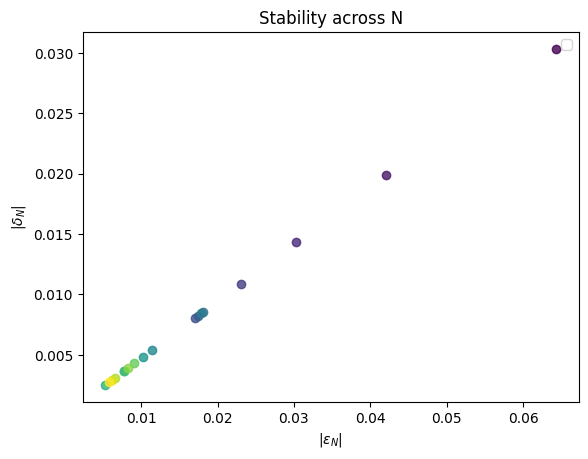

In [113]:
plt.figure()

for N in Ns:
    eps, delt = results[N]
    plt.scatter(eps.mean(), delt.mean(), c=N, vmin=min(Ns), vmax=max(Ns), alpha=0.8)

plt.xlabel("$|\\varepsilon_N|$")
plt.ylabel("$|\\delta_N|$")
plt.title("Stability across N")
plt.legend()
plt.show()

In [105]:
xs = np.linspace(-2, 2, 10)
ys = np.linspace(0.05, 1.5, 10)

Z_abs_err = np.zeros((len(ys), len(xs)))
N = 500

H = wigner_matrix(N)
for i, y in enumerate(ys):
    for j, x in enumerate(xs):
        z = x + 1j*y

        mN = empirical_m(H, z)   # or average over trials
        m = m_sc(z)

        Z_abs_err[i, j] = np.abs(mN - m)

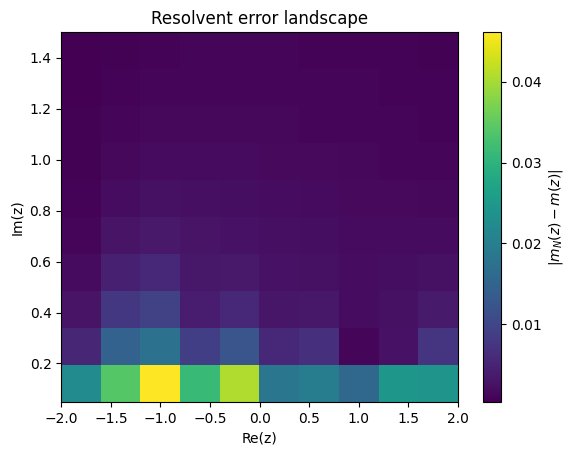

In [106]:
plt.figure()
plt.imshow(
    Z_abs_err,
    extent=[xs.min(), xs.max(), ys.min(), ys.max()],
    aspect="auto",
    origin="lower"
)
plt.colorbar(label=r"$|m_N(z) - m(z)|$")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.title("Resolvent error landscape")
plt.show()

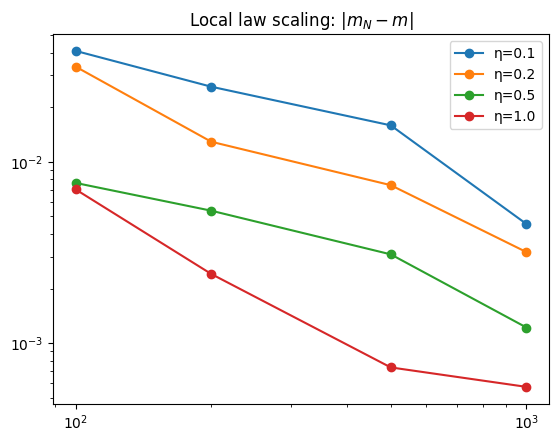

In [108]:
etas = [0.1, 0.2, 0.5, 1.0]
Ns = [100, 200, 500, 1000]
num_trials = 10

for eta in etas:
    errs = []
    for N in Ns:
        vals = []
        for _ in range(num_trials):
            H = wigner_matrix(N)
            z = 1.0 + 1j*eta
            vals.append(abs(empirical_m(H, z) - m_sc(z)))
        errs.append(np.mean(vals))
    plt.plot(Ns, errs, marker='o', label=f"η={eta}")

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title(r"Local law scaling: $|m_N - m|$")
plt.show()

TypeError: 'list' object is not callable

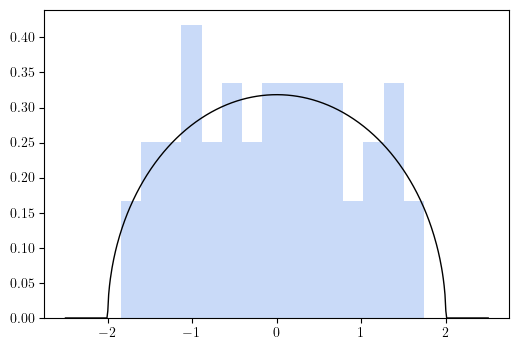

In [217]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Sampling functions
# ----------------------------

def symmetrize(X):
    return (X + X.T) / np.sqrt(2)

def sample_A(N):
    return np.random.normal(0, 1/np.sqrt(N), (N, N))

def sample_B(N):
    X = np.random.choice([-1, 1], size=(N, N)) / np.sqrt(N)
    return X

def sample_C(N):
    Y = np.random.exponential(scale=1.0, size=(N, N))
    X = (Y - 1.0) / np.sqrt(N)
    return X

def semicircle_density(x):
    return (1 / (2 * np.pi)) * np.sqrt(np.maximum(0, 4 - x**2))

# ----------------------------
# Plot empirical spectral measure
# ----------------------------

def plot_spectrum(N, sampler, color, bins=60, title=""):
    X = symmetrize(sampler(N))
    eigs = np.linalg.eigvalsh(X)

    plt.figure(figsize=(6, 4))
    plt.hist(eigs, bins=bins, density=True, color=color)

    xs = np.linspace(-2.5, 2.5, 500)
    plt.plot(xs, semicircle_density(xs), 'black', lw=1, label="Semicircle law")
    plt.ylim([0, 0.4])
    plt.xlim([-2.3, 2.3])
    plt.tight_layout()

    filename = f"{title.replace(' ', '_')}_N{N}.png"
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

# ----------------------------
# Run experiments
# ----------------------------

Ns = [50]
bins = [15, 40, 60]
colors = ['red', 'green', 'blue']

for i, N in enumerate(Ns):
    plot_spectrum(N, sample_A, '#C9DAF8', bins[i], "A")
    plot_spectrum(N, sample_B, '#F4CCCC', bins[i], "B")
    plot_spectrum(N, sample_C, '#D9EAD3', bins[i], "C")

In [150]:
import numpy as np
import matplotlib.pyplot as plt



# ----------------------------
# Parameters
# ----------------------------

etas = [0.1, 0.25, 0.5, 1.0, 2.0]
Re_z = 1.0

Ns = np.arange(50, 2001, 50)  # adjust resolution if needed

results = {eta: [] for eta in etas}

# ----------------------------
# Main experiment
# ----------------------------

num_trials = 10  # number of independent Wigner samples

results = {eta: [] for eta in etas}

for N in Ns:

    # store errors across trials for this N
    temp_errors = {eta: [] for eta in etas}

    for _ in range(num_trials):

        H = wigner_matrix(N)
        eigs = np.linalg.eigvalsh(H)

        for eta in etas:
            z = Re_z + 1j * eta

            mN = empirical_m(H, z)
            mlim = m_sc(z)

            err = np.abs(mN - mlim)
            temp_errors[eta].append(err)

    # average over trials
    for eta in etas:
        results[eta].append(np.mean(temp_errors[eta]))
# ----------------------------
# Plot
# ----------------------------

plt.figure(figsize=(7, 5))

colors = ['#8E7CC3', '#6D9EEB', '#93C47D', '#FCB26B', '#E06666']

for col, eta in zip(colors, etas):
    plt.plot(Ns, results[eta], label=fr"$\eta = {eta}$", color=col)

plt.yscale("log")
plt.legend()
plt.tight_layout()

plt.savefig("scconv.png", dpi=300, bbox_inches="tight")
plt.close()

In [78]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

Ns = np.arange(50, 1001, 50)
num_trials = 10

z_list = [
    0 + 0.5j,
    1.5 + 0.25j,
    -1.9 + 0.2j,
]

slopes = []

plt.figure(figsize=(6, 5))

cmaplist = ["Blues", "Reds", "Greens", "Reds"] 
cols = ["blue", "red", "green", "red"]

for c, cmap, z in zip(cols, cmaplist, z_list):

    deltas = []
    epsilons = []

    for N in Ns:

        temp_d = []
        temp_e = []

        for _ in range(num_trials):
            H = wigner_matrix(N)

            mN = empirical_m(H, z)
            msc = m_sc(z)

            delta = np.abs(mN - msc)
            eps = np.abs(1 + z*mN + mN**2)

            temp_d.append(delta)
            temp_e.append(eps)

        deltas.append(np.mean(temp_d))
        epsilons.append(np.mean(temp_e))

    deltas = np.array(deltas)
    epsilons = np.array(epsilons)

    x = epsilons
    y = deltas

    slope, intercept = np.polyfit(x, y, 1)
    slopes.append(slope)

    plt.scatter(epsilons, deltas, c=Ns, cmap=cmap)
    xs = np.linspace(np.min(epsilons), 10e-1, 100)
    plt.scatter([], [], label=f"$z = {np.real(z):.2f} + {np.imag(z):.2f}i$", c=c)
    tau = 2 / np.min([np.abs(z - 2), np.abs(z + 2)])
    plt.plot(xs, tau * xs, alpha=0.6, c=c, linestyle='dotted')


plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.tight_layout()
plt.xlim(right=1e-1)
plt.ylim(top=1e-1)
plt.savefig("dyson.png", dpi=300, bbox_inches="tight")
plt.close()

In [172]:
1/np.abs(-2 - (-1.8 + 0.5j))

np.float64(1.8569533817705188)